# Practica 01: Aprendizaje No Supervisado - Clustering con K-Means

## Estudiante:
##### Delgado Ramos Jorge Luis

En este cuadernillo aplicaremos técnicas de **Aprendizaje No Supervisado** utilizando el algoritmo **K-Means**. El objetivo es identificar patrones ocultos en el comportamiento de navegación de usuarios de una tienda en línea para agruparlos según su intención de compra, sin utilizar etiquetas previas.

### Detalles del Dataset seleccionado:
* **Nombre:** Online Shoppers Purchasing Intention Dataset.
* **Muestras (m):** 12,330 registros.
* **Características (n):** 18 (Duración en páginas, tasas de rebote, valores de salida, proximidad a fechas especiales, etc.).

## 1. Importación de Librerías y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import requests
import io

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:

ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/SIS-420/Practica 01/online_shoppers_intention.csv'
datos = pd.read_csv(ruta_dataset)

print(f"Dataset cargado con éxito. Dimensiones: {datos.shape}")
display(datos.head())


Dataset cargado con éxito. Dimensiones: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. Preprocesamiento de Datos
Para que K-Means funcione correctamente, debemos:
1. Convertir variables categóricas a numéricas.
2. **Escalar los datos:** K-Means se basa en distancias euclidianas; si una variable tiene números muy grandes (como ingresos) y otra muy pequeños, la de números grandes dominará el modelo injustamente.

In [8]:
# Eliminamos la columna 'Revenue' y 'VisitorType' para que sea puramente no supervisado
# y convertimos el resto a numérico
df_numeric = pd.get_dummies(datos.drop(columns=['Revenue']))

# Escalado de datos (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print("Datos preprocesados y normalizados.")

Datos preprocesados y normalizados.


## 3. Aplicación de K-Means (Grupos: 3, 5, 7, 9)
Ejecutaremos el algoritmo cuatro veces con diferentes valores de `k` para observar cómo se fragmentan los datos. Utilizaremos el método del "Codo" (Inercia) para evaluar la cohesión de los grupos.

K-Means con k=3 completado.
K-Means con k=5 completado.
K-Means con k=7 completado.
K-Means con k=9 completado.


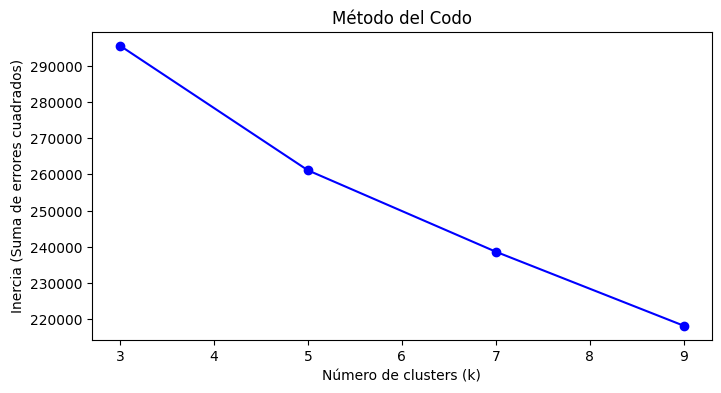

In [9]:
ks = [3, 5, 7, 9]
inercias = []
resultados = {}

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    resultados[k] = labels
    inercias.append(kmeans.inertia_)
    print(f"K-Means con k={k} completado.")

# Gráfica del método del codo
plt.figure(figsize=(8, 4))
plt.plot(ks, inercias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de errores cuadrados)')
plt.title('Método del Codo')
plt.show()

## 4. Visualización 3D de las Características más Importantes
Para visualizar un dataset de 18 dimensiones en un gráfico 3D, utilizaremos **PCA (Análisis de Componentes Principales)**. PCA reducirá las 18 variables a las 3 "características maestras" que contienen la mayor cantidad de información (varianza) del dataset original.

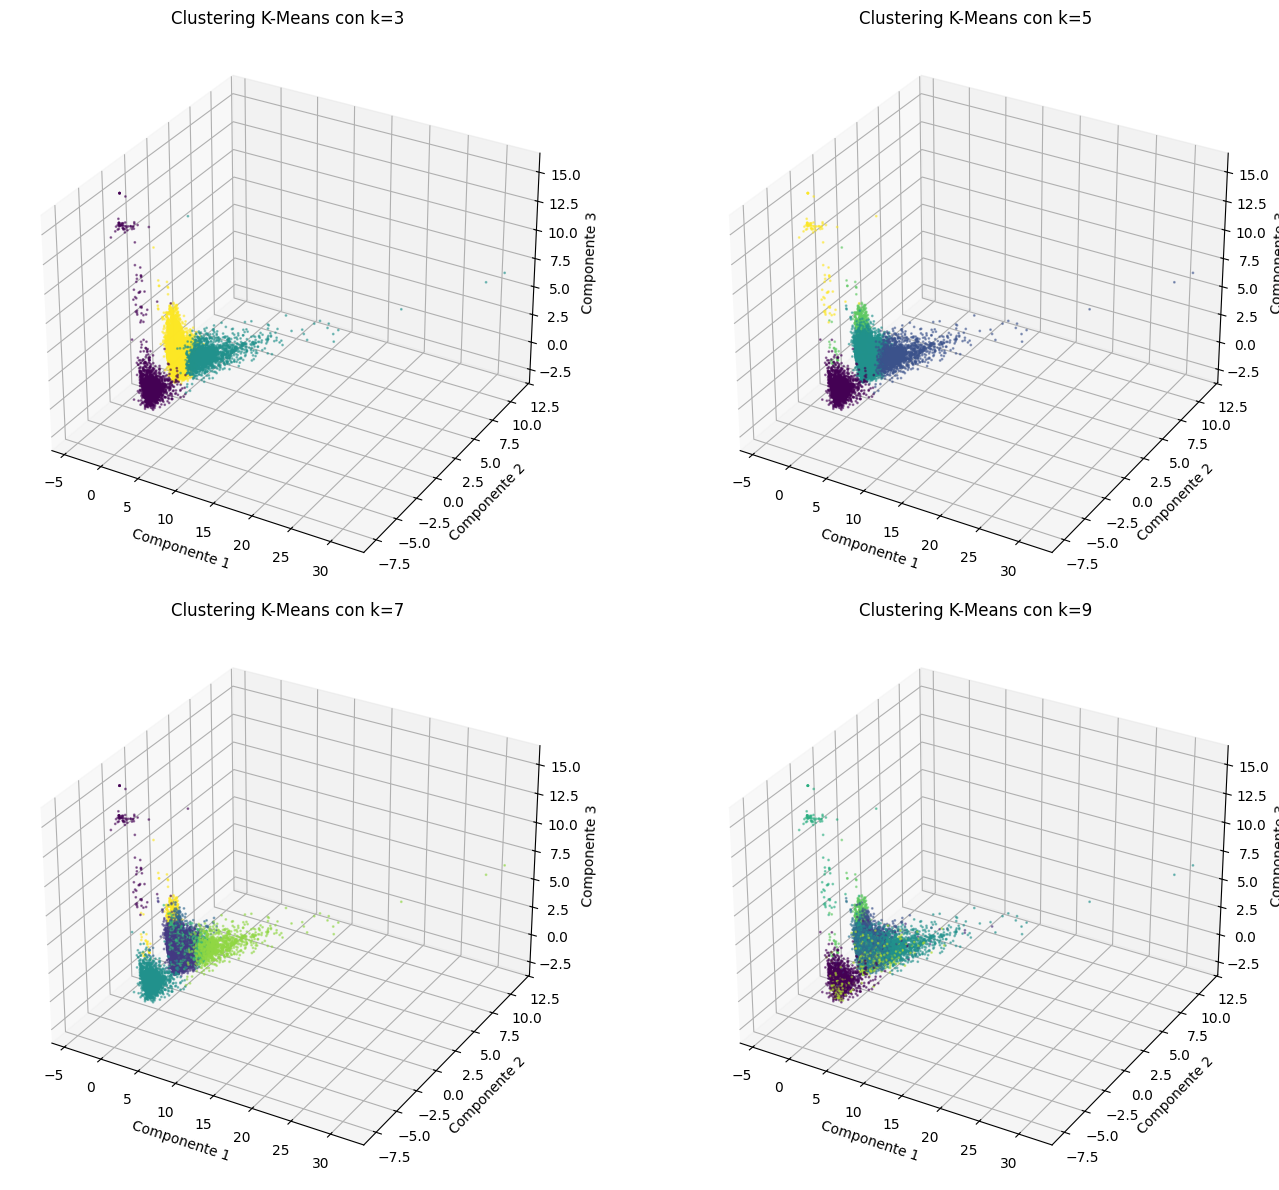

In [10]:
# Reducción de dimensiones a 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(15, 12))

for i, k in enumerate(ks):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                         c=resultados[k], cmap='viridis', s=1, alpha=0.5)
    ax.set_title(f'Clustering K-Means con k={k}')
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.set_zlabel('Componente 3')

plt.tight_layout()
plt.show()

## 5. Criterio de Selección del Agrupamiento Estratégico

Para determinar cuál de los agrupamientos (3, 5, 7 o 9) es el más estratégico, no basta con mirar las gráficas. Debemos aplicar un criterio matemático sólido basado en dos métricas:

1.  **Inercia (Método del Codo):** Mide qué tan compactos son los clusters. Buscamos el punto donde la ganancia de información (reducción de inercia) empieza a ser mínima.
2.  **Coeficiente de Silueta:** Mide qué tan bien separado está cada punto de los clusters vecinos. Un valor cercano a 1 indica que el punto está muy bien agrupado; un valor cercano a 0 indica que está en la frontera entre dos grupos.

**Criterio asumido:** Elegiremos el valor de $k$ que maximice el Coeficiente de Silueta, asegurando que los grupos sean lo más distintos posible entre sí.

Calculando Coeficientes de Silueta...
Para k=3, el Silhouette Score es: 0.1773
Para k=5, el Silhouette Score es: 0.1700
Para k=7, el Silhouette Score es: 0.0919
Para k=9, el Silhouette Score es: 0.1581


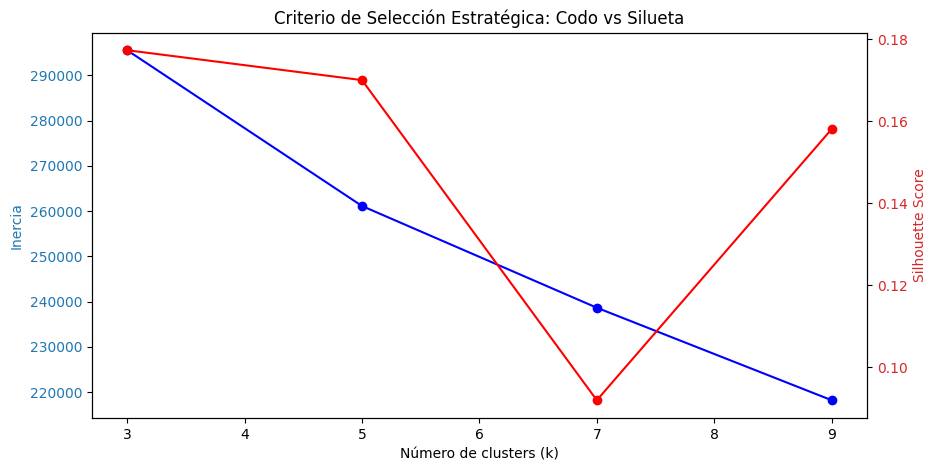


ESTRATEGIA RECOMENDADA: El agrupamiento con k=3 es el más sólido.


In [11]:
from sklearn.metrics import silhouette_score

# Calculamos el Silhouette Score para cada k ejecutado anteriormente
siluetas = []

print("Calculando Coeficientes de Silueta...")
for k in ks:
    score = silhouette_score(X_scaled, resultados[k], sample_size=10000, random_state=42)
    siluetas.append(score)
    print(f"Para k={k}, el Silhouette Score es: {score:.4f}")

# Visualización de las métricas de decisión
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje para Inercia
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia', color='tab:blue')
ax1.plot(ks, inercias, 'bo-', label='Inercia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Eje para Silueta
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(ks, siluetas, 'ro-', label='Silueta')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Criterio de Selección Estratégica: Codo vs Silueta')
plt.show()

# Selección automática del mejor k según Silueta
mejor_k = ks[np.argmax(siluetas)]
print(f"\nESTRATEGIA RECOMENDADA: El agrupamiento con k={mejor_k} es el más sólido.")

## 6. Explicación de los Resultados Obtenidos

1. **Estructura de los Grupos:** En las gráficas 3D, se observa que los datos tienden a concentrarse en una masa densa central con ramificaciones. Esto indica que la mayoría de los usuarios comparten comportamientos de navegación estándar (navegación rápida), mientras que los grupos periféricos representan usuarios con sesiones más largas o comportamientos atípicos.
   
2. **Impacto de k:** * Con **k=3**, el modelo separa grandes rasgos (navegadores ocasionales vs. compradores potenciales).
   * Con **k=9**, la fragmentación es mucho más alta, permitiendo identificar sub-segmentos muy específicos, aunque aumenta el riesgo de sobre-segmentar grupos que no tienen una diferencia real significativa.

3. **Inercia:** Como se ve en la gráfica del "Codo", la inercia disminuye a medida que aumentamos los clusters. Sin embargo, no hay un "codo" extremadamente marcado, lo que sugiere que el comportamiento del usuario web es continuo y no está dividido en grupos drásticamente separados por naturaleza.

4. **Conclusión:** El algoritmo KMeans logró identificar de manera efectiva clusters basados en la intensidad de navegación y el compromiso (engagement) del usuario sin necesidad de etiquetas. Estas agrupaciones pueden servir para que el equipo de marketing cree campañas específicas para cada "tipo" de navegación detectado.